# L15: The HR diagram
We will work with a star catalogue of 240 stars described by the following information:
- Temperature (in Kelvin)
- Luminosity (L/Lo)
- Radius (R/Ro)
- Absolute magnitude (Mv)

We also have the following data for each star:

- Color (Red/Orange/Yellow/White/Blue)
- Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
- Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)

In [17]:
import numpy as np
from matplotlib import pyplot as plt
import urllib.request
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [18]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x158bc8fc0>)

In [19]:
df_stars = pd.read_csv("stars.csv")

In [20]:
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


There are 6 star types that are encoded in the 'Star type' column. These labels are currently encoded as strings which is practical for reading but not for computing. Using scikit-learn, we will convert this column into integers by assigning a unique int value to each star type.

In [21]:
le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


It is often grood practice to start with a statistical analysis of the dataset to answer the following questions:
- are there any missing values?
- are there NaNs in the data?

Star classification is something that can be done based on rules depending on temperature and luminosity. 

In [22]:
df_stars['Star color'] = le.fit_transform(df_stars['Star color'])
df_stars['Spectral Class'] = le.fit_transform(df_stars['Spectral Class'])

print(df_stars.isnull().sum())
print("Contains NaN?", df_stars.isna().any().any())

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64
Contains NaN? False


We can reproduce the HR diagram by plotting the scatter plot of our stars using the same variables in log-log-scale.

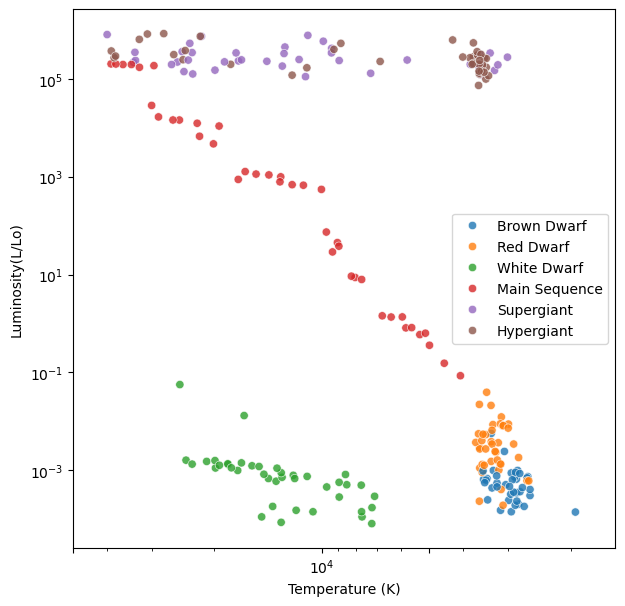

In [23]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, alpha=0.8, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

We find the same organization of stars in this 2D plane. Main Sequence stars and White Dwarves are fairly easy to isolate from the rest: a statistical model should be able to easily classify them. Based only on Luminosity and Temperature, Dwarf stars and Giant stars have higher intra-group variability: Supergiant and Hypergiant cover the same space (same for Brown and Red Dwarves). Additionnal variables might be needed to correctly identify the types of those stars.

1. Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
2. Project the dataset into the principal components, and do a scatter plot of the first two.
3. This will look terrible. Think about the units!
4. Explore what happens if you rescale the data first.

- You can try an linear, affine transformation such that each dimension goes between -1 and 1.
- Or (which is the usual machine-learning approach) standardize your data such that each dimension has mean=0 and variance=1.
- Redo your PCA. Should be much much better.
- How much variance is explained by those two components?

### PCA without rescaling

(240, 2)
(240, 2)
(2, 4)


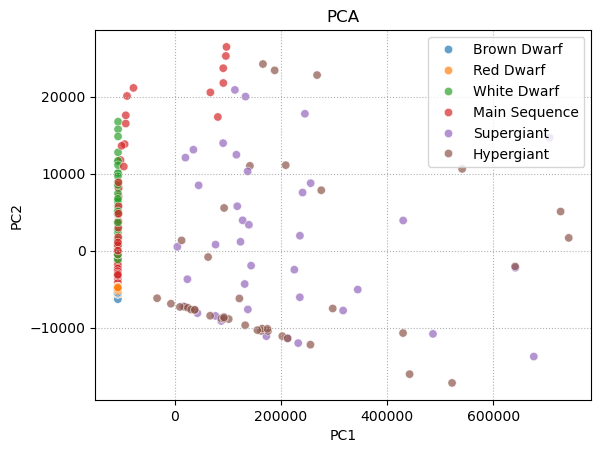

In [24]:
# Choose only the numerical columns
features = ['Temperature (K)',	'Luminosity(L/Lo)',	'Radius(R/Ro)',	'Absolute magnitude(Mv)']
X = df_stars[features]
n_comp = 2
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X) 

print(X_pca.shape)

eigenvalues = pca.transform(X) 
mean = pca.mean_ 
eigenvectors = pca.components_ 

print(eigenvalues.shape)
print(eigenvectors.shape)

sns.scatterplot(x=eigenvalues[:, 0], y=eigenvalues[:, 1], alpha=0.7, hue = labels)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
plt.show()

It looks very bad... let's rescale the data.
### PCA with rescaling data

In [25]:
# Scale the data: mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# apply PCA reduction
pca_scaled = PCA(n_components=n_comp)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

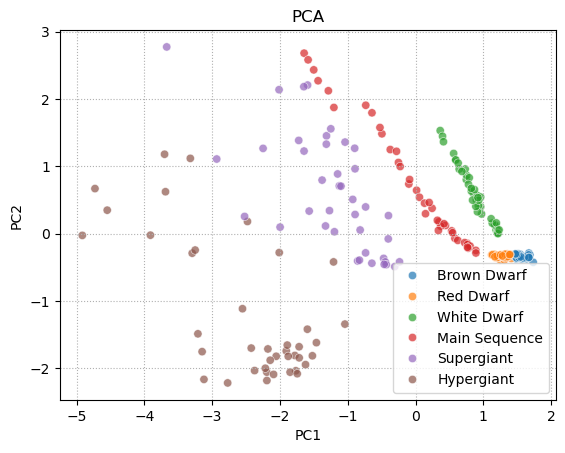

Explained variance (scaled): [0.60357391 0.23500784]
Total variance explained by PC1 and PC2: 83.86%
(240, 2)


In [26]:
# plot
sns.scatterplot(x=X_pca_scaled[:, 0], y=X_pca_scaled[:, 1], alpha=0.7, hue = labels)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
plt.show()

# Print explained variance
exp_variance = pca_scaled.explained_variance_ratio_
print("Explained variance (scaled):", exp_variance)
print(f"Total variance explained by PC1 and PC2: {exp_variance.sum() * 100:.2f}%")
print(eigenvalues.shape)

### Let's try a linear transformation such that each dimension goes from -1 to 1.

In [27]:
# Rescaling tra -1 e 1
minmax_scaler = MinMaxScaler(feature_range=(-1, 1))
X_minmax = minmax_scaler.fit_transform(X)

pca_minmax = PCA(n_components=n_comp)
X_pca_minmax = pca_minmax.fit_transform(X_minmax)

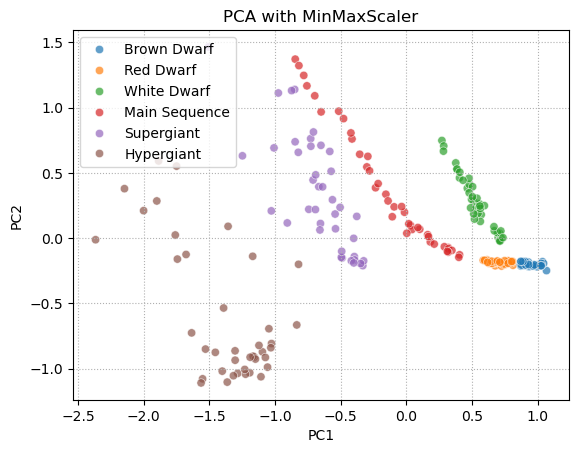

Explained variance (scaled): [0.63752162 0.21432776]
Total variance explained by PC1 and PC2: 85.18%
(240, 2)


In [28]:
pca_minmax = PCA(n_components=n_comp)
X_pca_minmax = pca_minmax.fit_transform(X_minmax)
# plot
sns.scatterplot(x=X_pca_minmax[:, 0], y=X_pca_minmax[:, 1], alpha=0.7, hue = labels)
plt.title("PCA with MinMaxScaler")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
plt.show()

# Print explained variance
exp_variance_minmax = pca_minmax.explained_variance_ratio_
print("Explained variance (scaled):", exp_variance_minmax)
print(f"Total variance explained by PC1 and PC2: {exp_variance_minmax.sum() * 100:.2f}%")
print(eigenvalues.shape)

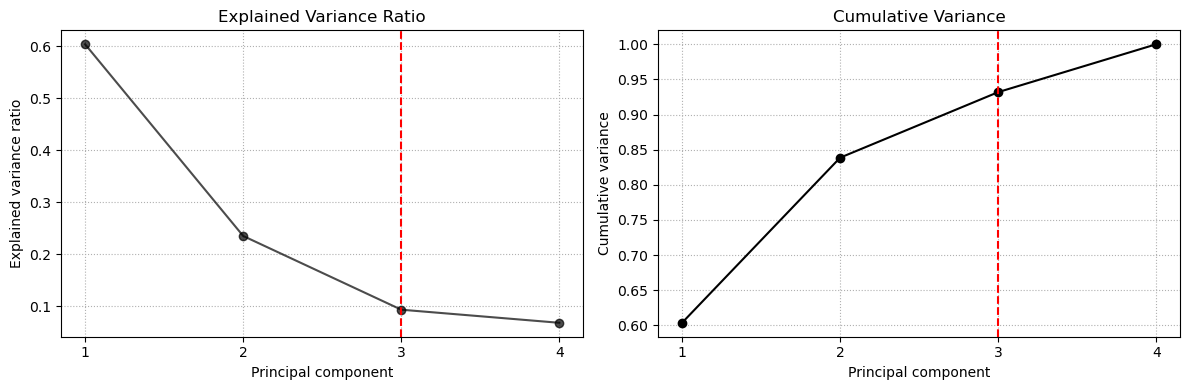

Number of Principal components required for a cumulative variance > 90%: 3


In [29]:
n = X.shape[1]
#print(n)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca_full = PCA(n_components=n)
X_pca = pca_full.fit_transform(X_scaled)

# Explained variance ratio and cumulative variance
exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

threshold = 0.90
elbow_index = np.argmax(cum_exp_var >= threshold)+1

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. plot explained variance
ax[0].plot(range(1, len(exp_var) + 1), exp_var, marker='o', linestyle='-', color='black', alpha=0.7, label='Explained variance')
ax[0].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
ax[0].set_ylabel('Explained variance ratio')
ax[0].set_xlabel('Principal component')
ax[0].set_xticks(range(1, len(exp_var) + 1))
ax[0].set_title("Explained Variance Ratio")
ax[0].grid(True, linestyle=':')


# 2. plot cumulative variance
ax[1].plot(range(1, len(cum_exp_var) + 1), cum_exp_var, marker='o', linestyle='-', label='Cumulative variance', color='black')
ax[1].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
ax[1].set_ylabel('Cumulative variance')
ax[1].set_xlabel('Principal component')
ax[1].set_xticks(range(1, len(exp_var) + 1))
ax[1].set_title("Cumulative Variance")
ax[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

print(f"Number of Principal components required for a cumulative variance > 90%: {elbow_index}")

PCA is a **linear** process, whereas the variations in the data may not be. Because of this, it is not always the most efficient method and may require a relatively large number of principal components to fully capture any non-linearities.
In our dataset, the relationships between features (like luminosity, radius, and temperature) are highly **non-linear**. A good strategy is to convert the data to a log-scale in order to linearize these physical relationships before applying PCA.

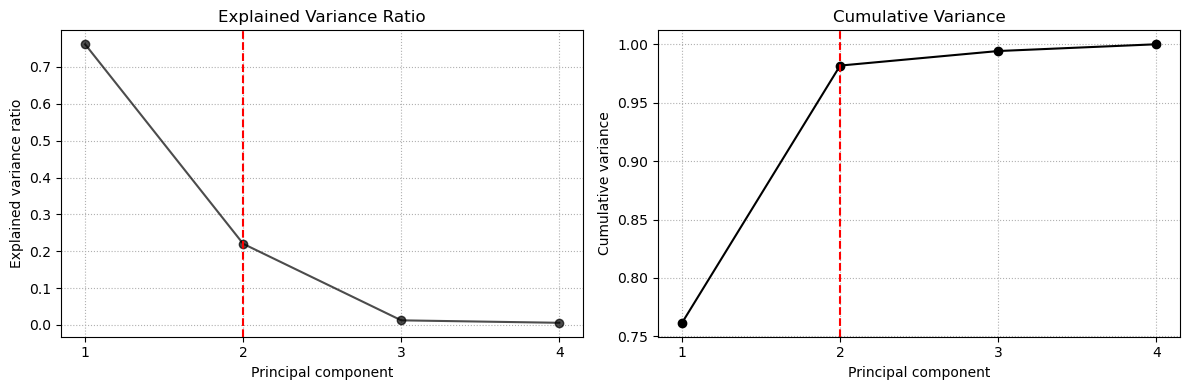

Number of Principal components required for a cumulative variance > 90%: 2


In [30]:
X_log = df_stars[features].copy()

# Applica log10 a Temperature e Luminosity
X_log['Temperature (K)'] = np.log10(X_log['Temperature (K)'])
X_log['Luminosity(L/Lo)'] = np.log10(X_log['Luminosity(L/Lo)'])
X_log['Radius(R/Ro)'] = np.log10(X_log['Radius(R/Ro)'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Apply PCA
pca_full = PCA(n_components=n)
X_pca = pca_full.fit_transform(X_scaled)
X_original = scaler.inverse_transform(X_scaled)

# Explained variance ratio and cumulative variance
exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

threshold = 0.90
elbow_index = np.argmax(cum_exp_var >= threshold)+1

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. plot explained variance
ax[0].plot(range(1, len(exp_var) + 1), exp_var, marker='o', linestyle='-', color='black', alpha=0.7, label='Explained variance')
ax[0].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
ax[0].set_ylabel('Explained variance ratio')
ax[0].set_xlabel('Principal component')
ax[0].set_xticks(range(1, len(exp_var) + 1))
ax[0].set_title("Explained Variance Ratio")
ax[0].grid(True, linestyle=':')


# 2. plot cumulative variance
ax[1].plot(range(1, len(cum_exp_var) + 1), cum_exp_var, marker='o', linestyle='-', label='Cumulative variance', color='black')
ax[1].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
ax[1].set_ylabel('Cumulative variance')
ax[1].set_xlabel('Principal component')
ax[1].set_xticks(range(1, len(exp_var) + 1))
ax[1].set_title("Cumulative Variance")
ax[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

print(f"Number of Principal components required for a cumulative variance > 90%: {elbow_index}")

### Let's see the scatter plot in the log-space

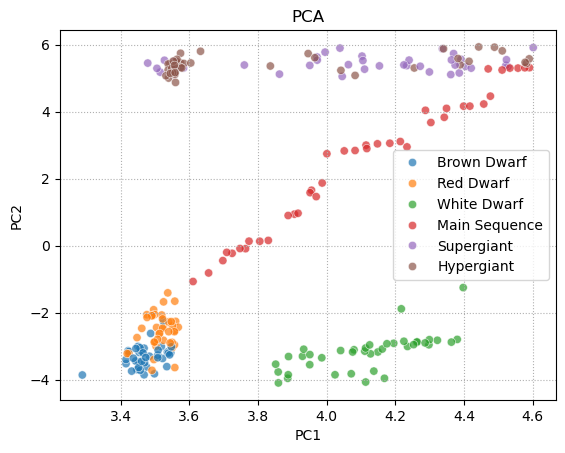

Explained variance (scaled): [0.76162934 0.22012559]
Total variance explained by PC1 and PC2: 98.18%
(240, 2)


In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Apply PCA
pca_log = PCA(n_components=n_comp)
X_pca_log = pca_log.fit_transform(X_scaled)
X_original = scaler.inverse_transform(X_scaled)

# plot
sns.scatterplot(x=X_original[:, 0], y=X_original[:, 1], alpha=0.7, hue = labels)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(linestyle = ":")
plt.show()

# Print explained variance
exp_variance_log = pca_log.explained_variance_ratio_
print("Explained variance (scaled):", exp_variance_log)
print(f"Total variance explained by PC1 and PC2: {exp_variance_log.sum() * 100:.2f}%")
print(eigenvalues.shape)

**The total variance explained by only 2 components is now 98.18% !!**